# Predicting House Prices in California with `LinearRegression()`

In this lab you will start inspect, analyze, visualize house price data from different districts in California, US. After having performed analysis, EDA and some feature engineering, you will build your own `LinearRegression()`  with `SkLearn`.

In [2]:
import pandas as pd

df = pd.read_csv("/content/housing (5).csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Part 1 - Inspection and Cleaning


#### Import and Inspect your data

Read the `housing.csv` file and make use of some methods to understand your data better. Below is an explanation of the features you are going to work with:

1. **longitude:**  geographical coordinate, east to west position of district
2. **latitude:**  geographical coordinate, north to south position of district
3. **housing_median_age:** the median age of houses in district
4. **total_rooms** Sum of all rooms in district
5. **total_bedrooms** Sum of all bedrooms in district
6. **population:** total population in district
7. **households:** total households in district
8. **median_income:** median household income in district
9. **median_house_value:** median house value in district
10. **ocean_proximity:** District´s proximity to the ocean

In [5]:
housing = pd.read_csv("/content/housing (5).csv")



In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [8]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


#### Histograms
Make histograms of all your numeric columns in order to get a good understanding of the distribution of your data points. What do you see?

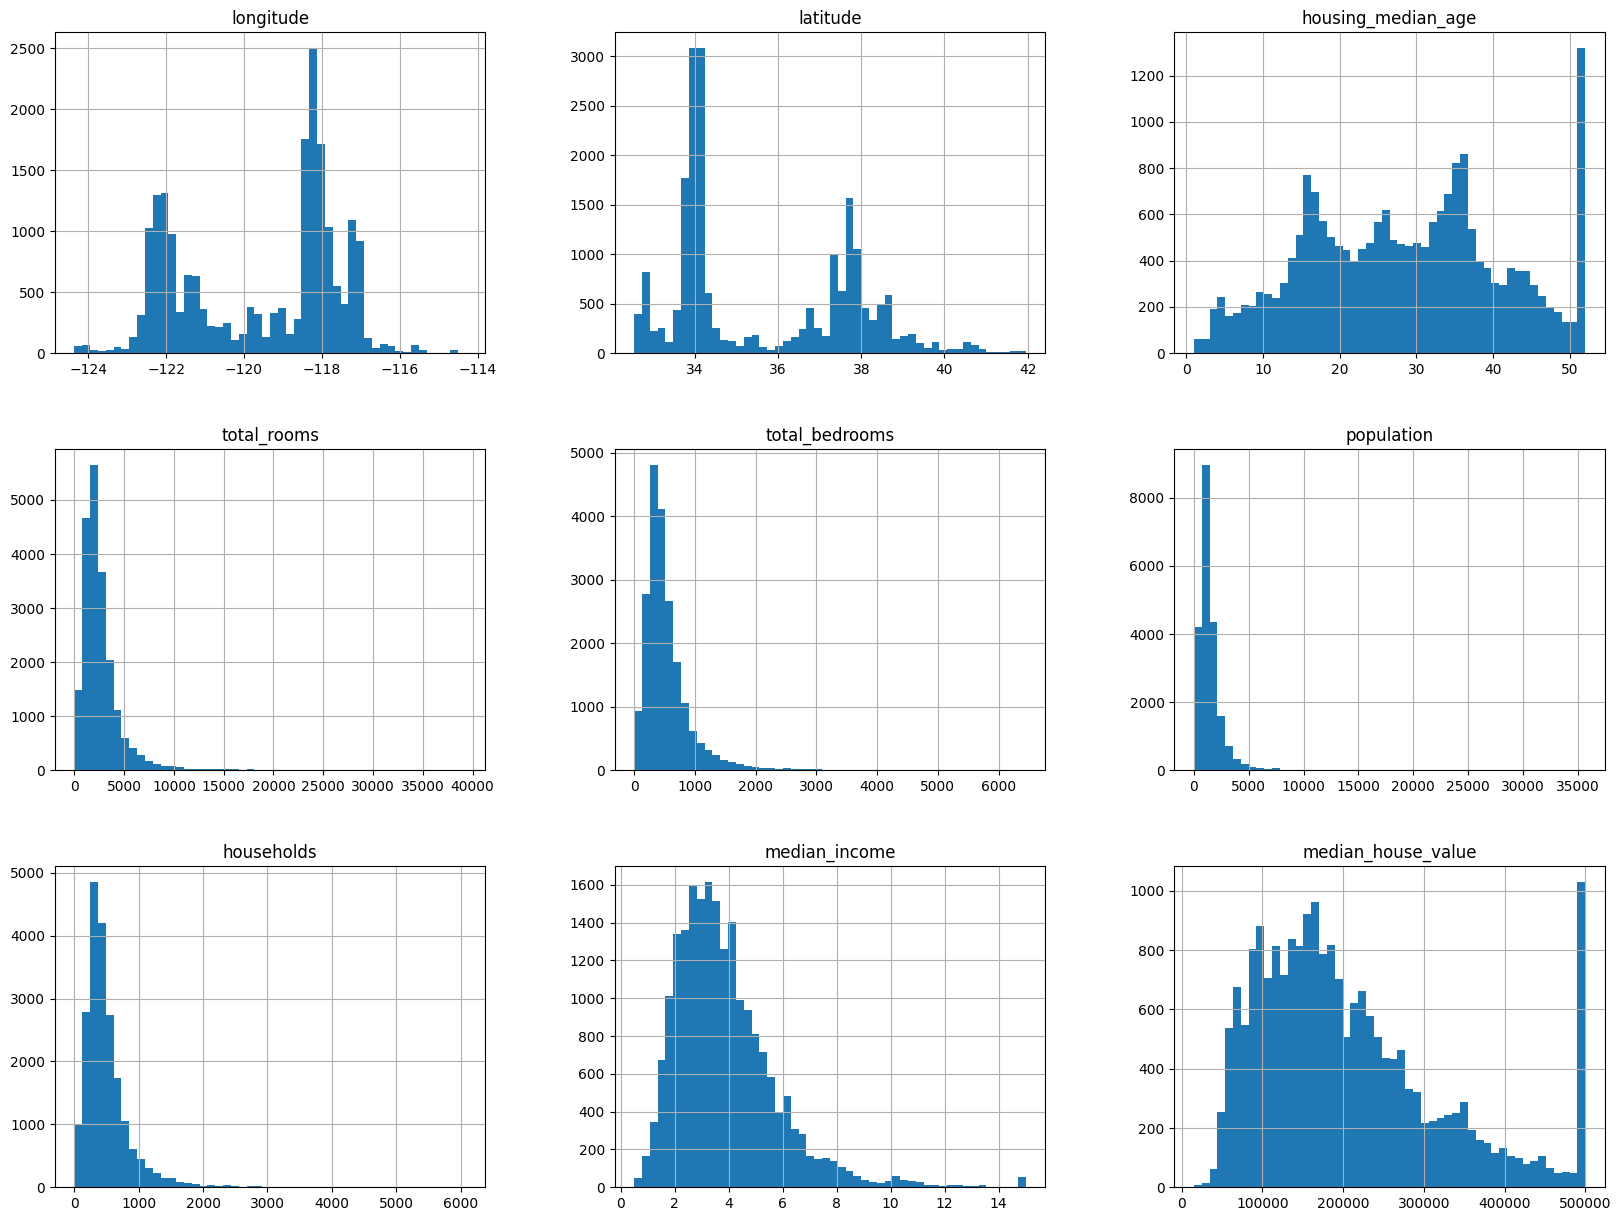

In [9]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

#### Let's create some features a tidy up our data

1. Locate your NaN values and make a decision on how to handle them. Drop, fill with mean, or something else, it is entirely up to you.

In [10]:
housing = housing.fillna(housing.mean(numeric_only=True))

2. Create three new columns by using simple arithmetic operations. Create one column with "rooms per household", one with "population per household",  and one with "bedrooms per room".

In [11]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]


In [12]:
housing["population_per_household"] = housing["population"] / housing["households"]

In [13]:
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

3. If you check the largest and smallest values of your "rooms per houshold column" you will see two outliers and two values that are just wrong. Drop the four values by index.

In [15]:
idx_to_drop = housing["rooms_per_household"].nlargest(2).index.union(housing["rooms_per_household"].nsmallest(2).index)
print(idx_to_drop)
housing = housing.drop(index=idx_to_drop)

Index([1913, 3126, 12447, 14818], dtype='int64')


# Part 2 - Exploratory Data Analysis



#### Let's find out what factors have an influence on our predicting variable

1. Let's check out the distribution of our "median house value". Visualize your results with 100 bins.

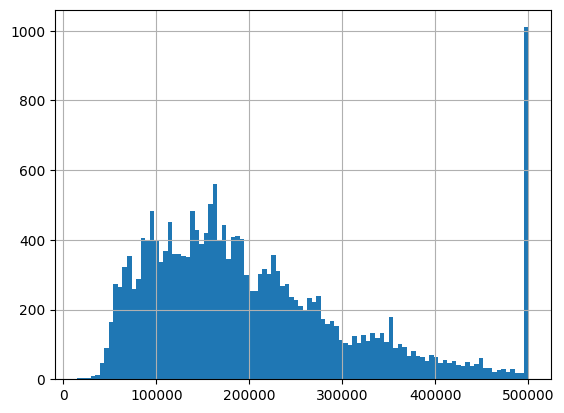

In [16]:
import matplotlib.pyplot as plt

housing["median_house_value"].hist(bins=100)
plt.show()

2. Check out what variables correlates the most with "median house value"

In [17]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688392
rooms_per_household,0.176598
total_rooms,0.134115
housing_median_age,0.105674
households,0.065920
total_bedrooms,0.049413
population_per_household,-0.023747
population,-0.024630
longitude,-0.045708


3. Let's check out the distribution of the column that has the highest correlation to "median house value". Visualize your results with 100 bins.

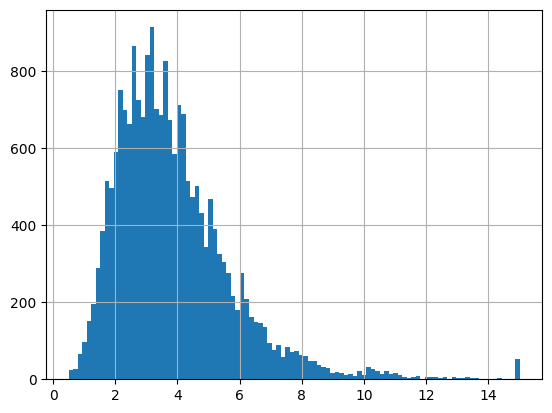

In [18]:
housing["median_income"].hist(bins=100)
plt.show()

4. Visualize the "median house value" and "median income" in a jointplot (kind="reg"). What do you see?

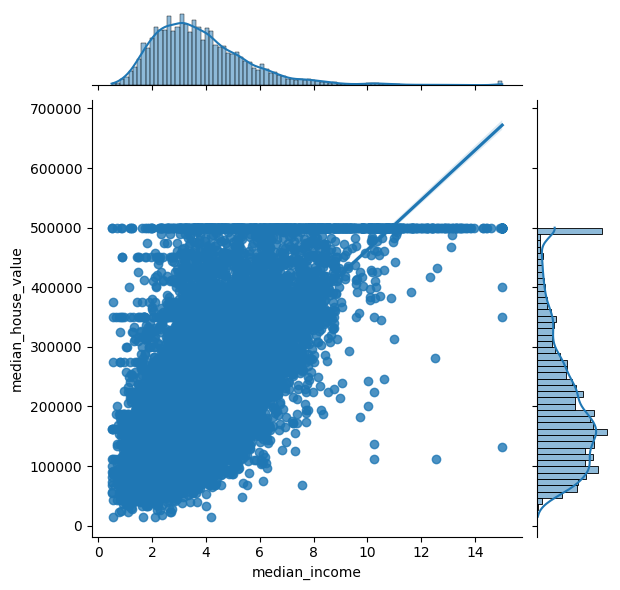

In [19]:
import seaborn as sns

sns.jointplot(data=housing, x="median_income", y="median_house_value", kind="reg")

5. Make the same visualization as in the above, but, cahnge the kind parameter to "kde". What extra information does this type of visualization convey, that the one in the above does not?

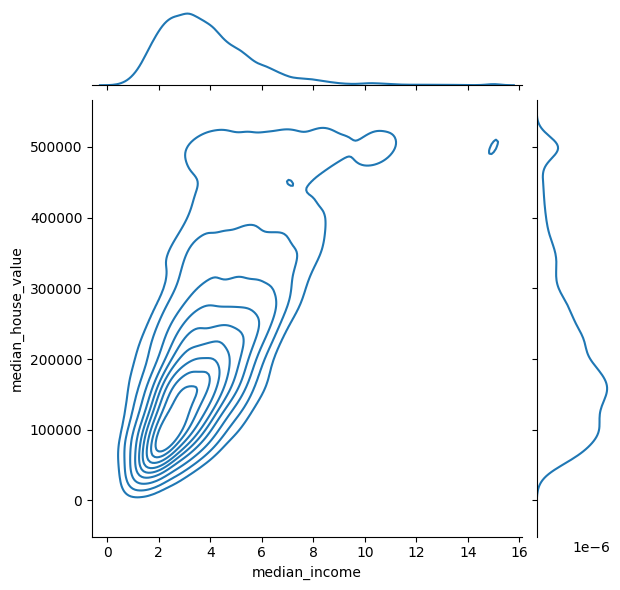

In [20]:
sns.jointplot(data=housing, x="median_income", y="median_house_value", kind="kde")

#### Let's get schwifty with some EDA

1. Create a new categorical column from the "median income" with the following quartiles `[0, 0.25, 0.5, 0.75, 0.95, 1]` and label them like this `["Low", "Below_Average", "Above_Average", "High", "Very High"]` and name the column "income_cat"

In [21]:
housing["income_cat"] = pd.qcut(housing["median_income"], q=[0,0.25,0.5,0.75,0.95,1], labels=["Low","Below_Average","Above_Average","High","Very High"])

2. Using the Seaborn library, plot the count of your new column and set the `hue` to "ocean_proximity". What interesting things can you see?

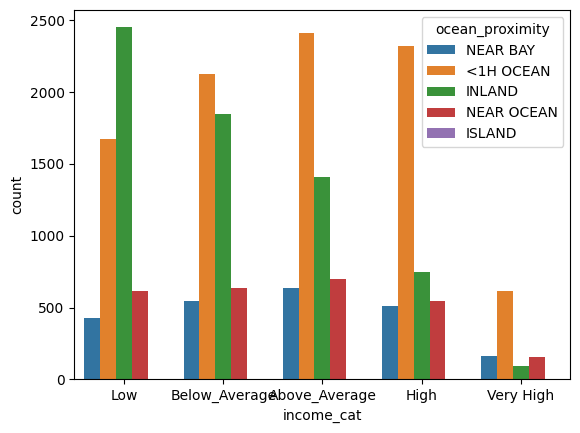

In [22]:
sns.countplot(data=housing, x="income_cat", hue="ocean_proximity")
plt.show()

3. Create two barplots where you set "y="median_house_value" on both, and the x is first "income cat" and then "ocean_proximity". How does these two graphs complement what you saw in the graph in your previous question?

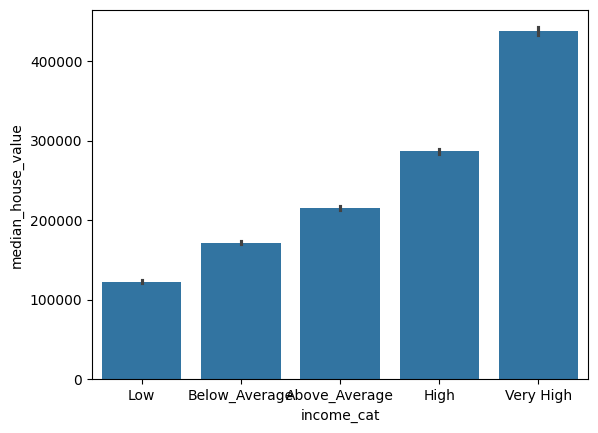

In [23]:
sns.barplot(data=housing, x="income_cat", y="median_house_value")
plt.show()

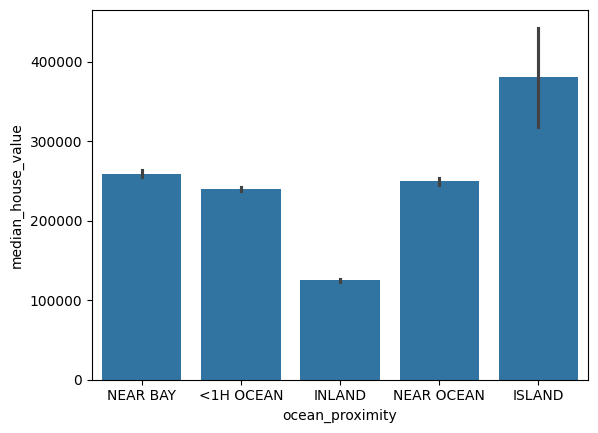

In [24]:
sns.barplot(data=housing, x="ocean_proximity", y="median_house_value")
plt.show()

4. Create a pivoted dataframe where you have the values of the "income cat" column as indices and the values of the "ocean_proximity" column as columns. Also drop the "ISLAND" column that you'll get.

In [26]:
pivot_df = housing.pivot_table(values="median_house_value", index="income_cat", columns="ocean_proximity")
pivot_df = pivot_df.drop(columns=["ISLAND"], errors="ignore")
pivot_df

/tmp/ipykernel_207/2611822673.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = housing.pivot_table(values="median_house_value", index="income_cat", columns="ocean_proximity")


ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,161286.295808,84592.482843,155709.169014,148170.476346
Below_Average,196951.657721,115210.726977,220160.244526,209471.397799
Above_Average,232015.206968,147598.154119,261814.637931,255814.151213
High,292114.036238,207855.890374,321951.358674,337934.853748
Very High,439648.851307,346034.531250,451015.078788,468739.723270


In [27]:
pivot_df = pivot_df.drop(columns=["ISLAND"], errors="ignore")
pivot_df

ocean_proximity,<1H OCEAN,INLAND,NEAR BAY,NEAR OCEAN
income_cat,,,,
Low,161286.295808,84592.482843,155709.169014,148170.476346
Below_Average,196951.657721,115210.726977,220160.244526,209471.397799
Above_Average,232015.206968,147598.154119,261814.637931,255814.151213
High,292114.036238,207855.890374,321951.358674,337934.853748
Very High,439648.851307,346034.531250,451015.078788,468739.723270


5. Turn your pivoted dataframe into a heatmap. The heatmap should have annotations in integer format.

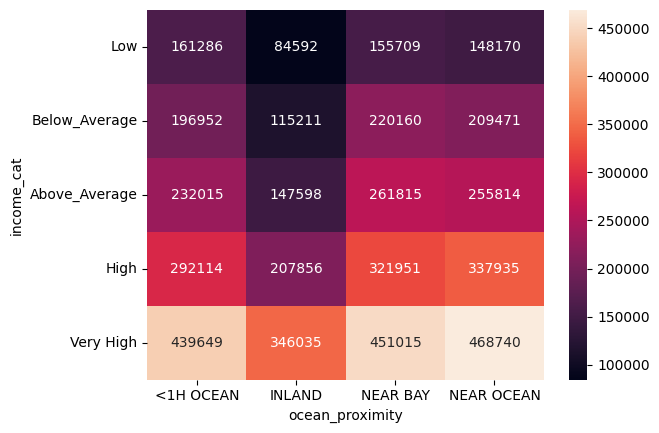

In [28]:
sns.heatmap(pivot_df, annot=True, fmt=".0f")
plt.show()

# Part 3 - Preparing your Data



#### Splitting, Preparing and Engineering some Features

1. Let's drop the "income_cat" column as it has served its purpose already. We don't need for our model as we already have "median income".
Not dropping "incom cat" will lead to multicolinearity.

In [29]:
housing = housing.drop(columns=["income_cat"], errors="ignore")

2. Select your floating point columns and standardize your data by calculating the Z-score. You can apply the `stats.zscore()` method in a lambda function. Save your results to a variable called `z_scored`.

In [30]:
import scipy.stats as stats

In [31]:
float_cols = housing.select_dtypes(include="float64").columns
z_scored = housing[float_cols].apply(lambda x: stats.zscore(x))

3. Turn the only categorical columns into dummies. Be vary of the dummy trap, to avoid multicolinearity.

In [32]:
housing = pd.get_dummies(housing, columns=["ocean_proximity"], drop_first=True)

4. Save our predicting variable to `y`.

In [33]:
y = housing["median_house_value"]

5. Concatenate `z_scored` and `dummies` and drop the predicting variable. Save to the varible `X`.

In [34]:
X = pd.concat([z_scored, housing.filter(like="ocean_proximity_")], axis=1).drop(columns=["median_house_value"], errors="ignore")

# Part 4 - Machine Learning




#### Train, Test, Split

1. Import `train_test_split` and split your data accordingly. Choose an appropriate test size.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Building and Training our Model

2. Build, fit and train a `LinearRegression` model.

In [36]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [37]:
model.fit(X_train, y_train)

LinearRegression()

3. In a scatterplot, visualize the y_train on your x-axis and your predictions on the y-axis. How does your training predictions look?

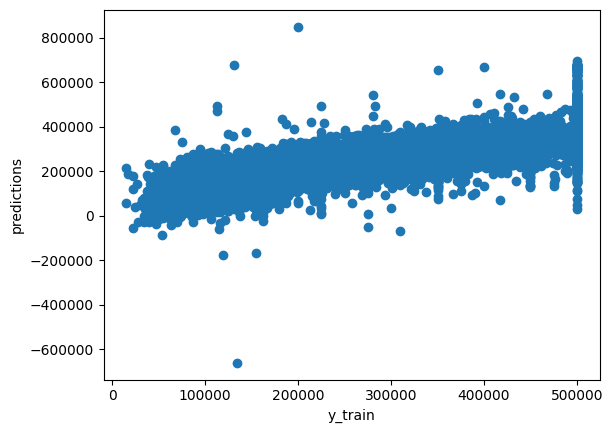

In [38]:
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train)

plt.scatter(y_train, y_train_pred)
plt.xlabel("y_train")
plt.ylabel("predictions")
plt.show()

4. From the sklearn metrics module, print the mean_squared_error and R^2-score. What does the metrics tell us?

In [39]:
from sklearn import metrics

In [40]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

4608449930.59867
0.6545644415802309


#### Final Predictions

1. Now you are ready to make prediction on the test data. Do that and visualize your results in a new scatterplot.

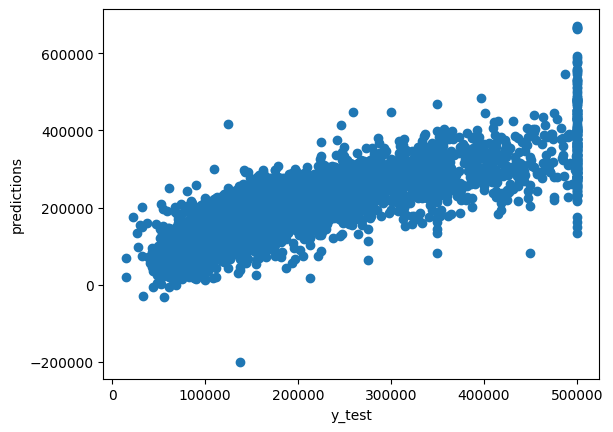

In [41]:
y_pred = model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("y_test")
plt.ylabel("predictions")
plt.show()

2. Print the mean_squared_error and R^2-score again. What has happened?

In [42]:
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

4608449930.59867
0.6545644415802309


3. There is another metric called Root mean squared error, Which is the square root of the MSE. Calculate the RMSE.

In [44]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

67885.56496486325


# Bonus Questions 1

1. Create a dataframe with two columns, one consisting of the y_test and one of your model's predictions.

In [45]:
import pandas as pd

results = pd.DataFrame({"y_test": y_test, "predictions": y_pred})
results

,y_test,predictions
13864,108300.0,89081.192287
1710,157800.0,236274.991688
9284,345000.0,310547.043013
10792,490800.0,383219.809938
19718,72500.0,84674.826131
...,...,...
8266,175000.0,218251.977285
20536,130800.0,119909.746369
16024,344200.0,307332.893995
2274,69600.0,116552.166171


2. Make a series of of your new dataframe, by calculating the predicted error in absolut numbers. Save this series to variable name `absolute_errors`.

In [46]:
absolute_errors = (results["y_test"] - results["predictions"]).abs()

3. If you take the mean of your series, you will get the mean absolute errors, which is another metric for Linear Regressions.

# Bonus Question 2 - Build a Random Forest Regressor

1. Build, fit and train a `RandomForestRegressor` model. Do this by following the same staps that you followed when building your `LinearRegression`.

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf = RandomForestRegressor()


In [52]:
rf.fit(X_train, y_train)

RandomForestRegressor()

In [51]:
y_pred_rf = rf.predict(X_test)

2. Make prediction on the test data and evaluate you results.

In [53]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred_rf = rf.predict(X_test)

print(mean_squared_error(y_test, y_pred_rf))
print(r2_score(y_test, y_pred_rf))
print(np.sqrt(mean_squared_error(y_test, y_pred_rf)))

2452715084.9373164
0.8161518476344064
49524.893588349245
